In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import nichepca as npc
import scanpy as sc
from jenkspy import JenksNaturalBreaks
from spatialtools.spatial import spatial_sample_split
from spatialtools.tls import plot_tls
from tqdm.auto import tqdm

In [2]:
path = "data/xenium/processed/05.1-kidney_tcr_nichepca.h5ad"
adata = sc.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 510139 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_c

## Density-based approach

In [3]:
# calc t cell density per cell neighborhood
npc.gc.construct_multi_sample_graph(
    adata, sample_key="sample", radius=50, remove_self_loops=False
)

  0%|          | 0/13 [00:00<?, ?it/s]

----------- Graph Stats -----------
Number of nodes: 510139
Number of edges: 28685343
Average in-degree: 56.230438232421875
Average out-degree: 56.230438232421875
Contains self-loops: True
Is undirected: True


In [4]:
# perform graph aggregation
import numpy as np
import pandas as pd

obs_key = "cell_type_l1"
backend = "sparse"
aggr = "mean"

df = pd.get_dummies(adata.obs[obs_key], dtype=np.int8)
X = df.values
var = pd.DataFrame(index=df.columns)

ad_tmp = sc.AnnData(
    X=X,
    obs=adata.obs,
    var=var,
    uns=adata.uns,
)
npc.ne.aggregate(ad_tmp, backend=backend, aggr=aggr, obsm_key=None, suffix="")

In [5]:
adata[adata.obs["cell_type_l1"] == "T"].obs["cell_type_l2"].value_counts()

cell_type_l2
CD4+        9258
CD8+        6509
NKT-like    1842
Tregs       1158
MAIT         820
gdT          446
Name: count, dtype: int64

In [6]:
tcell_density = np.asarray(ad_tmp[:, "T"].X).flatten()

In [17]:
# split into groups using jenkins natural breaks
n_groups = 5
jnb = JenksNaturalBreaks(n_groups)
jnb.fit(tcell_density)
groups = jnb.labels_.astype(str)

In [18]:
adata.obs["tcell_density_group"] = groups
adata.obs["tcell_density"] = tcell_density

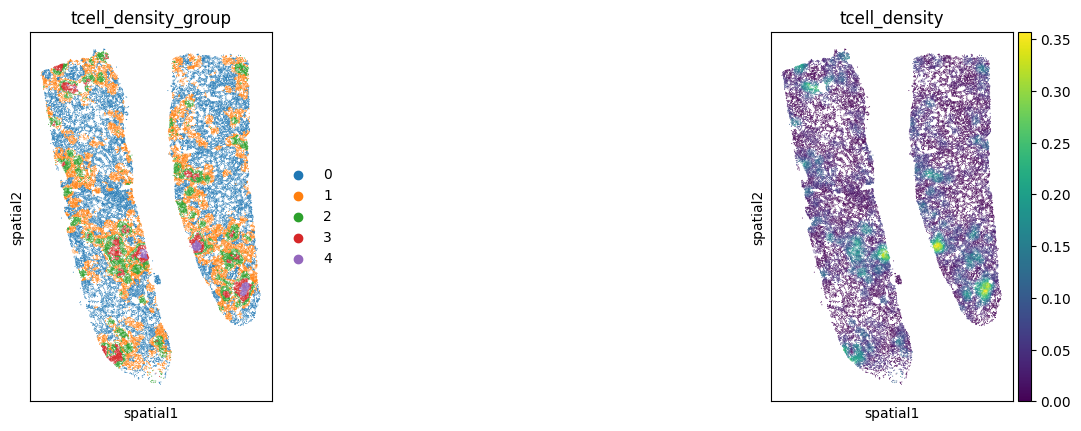

In [19]:
for sample in adata.obs["sample"].unique()[1:2]:
    ad_sub = adata[adata.obs["sample"] == sample].copy()
    sc.pl.spatial(ad_sub, color=["tcell_density_group", "tcell_density"], spot_size=10)

### Using threshold

In [14]:
threshold = 0.15
mask = tcell_density > threshold

adata.obs["tcell_infiltrate"] = "no infiltrate"
adata.obs.loc[mask, "tcell_infiltrate"] = "infiltrate"

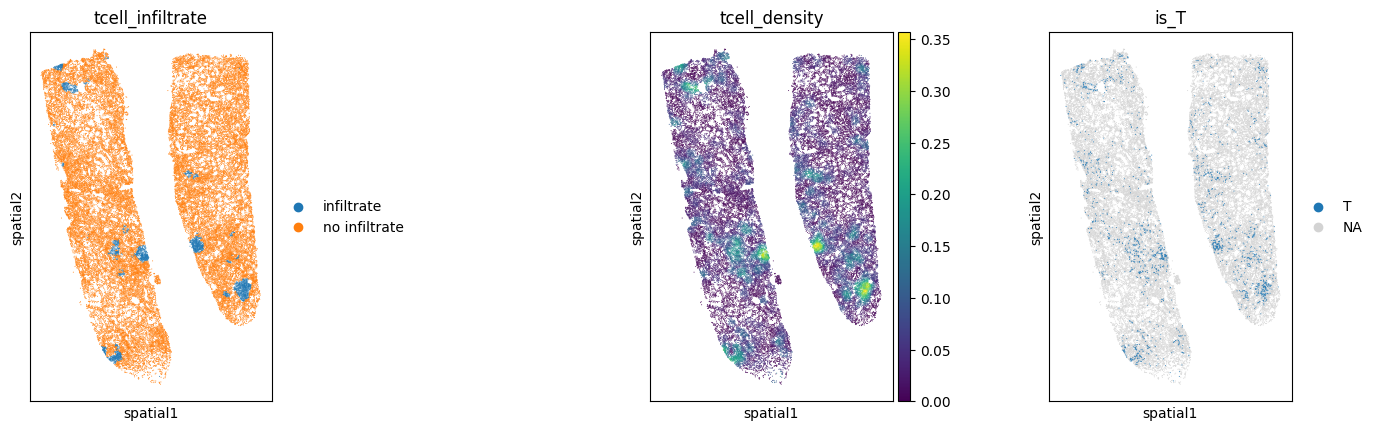

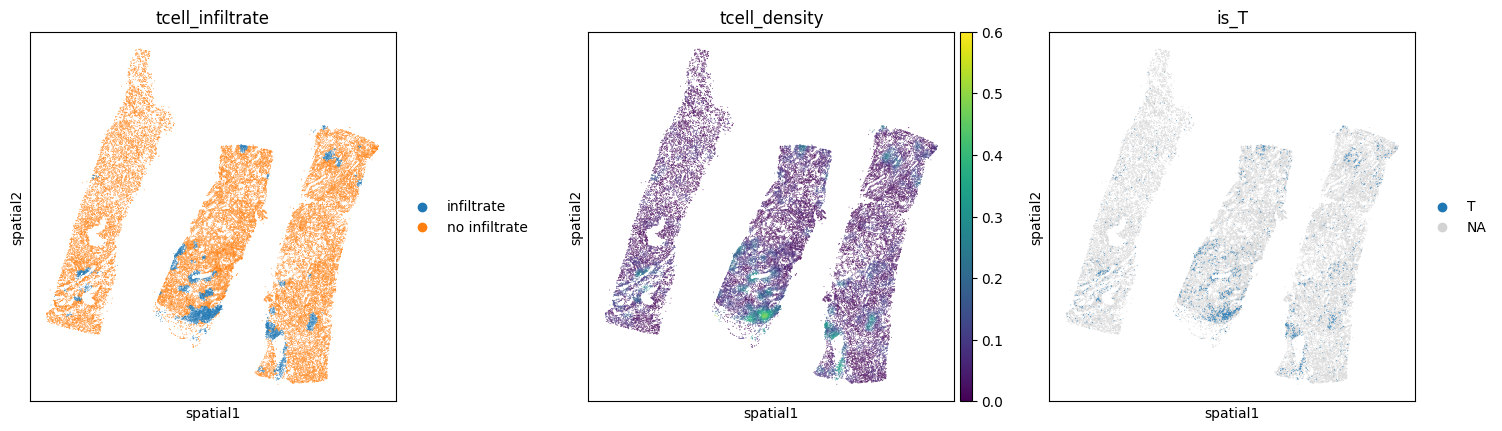

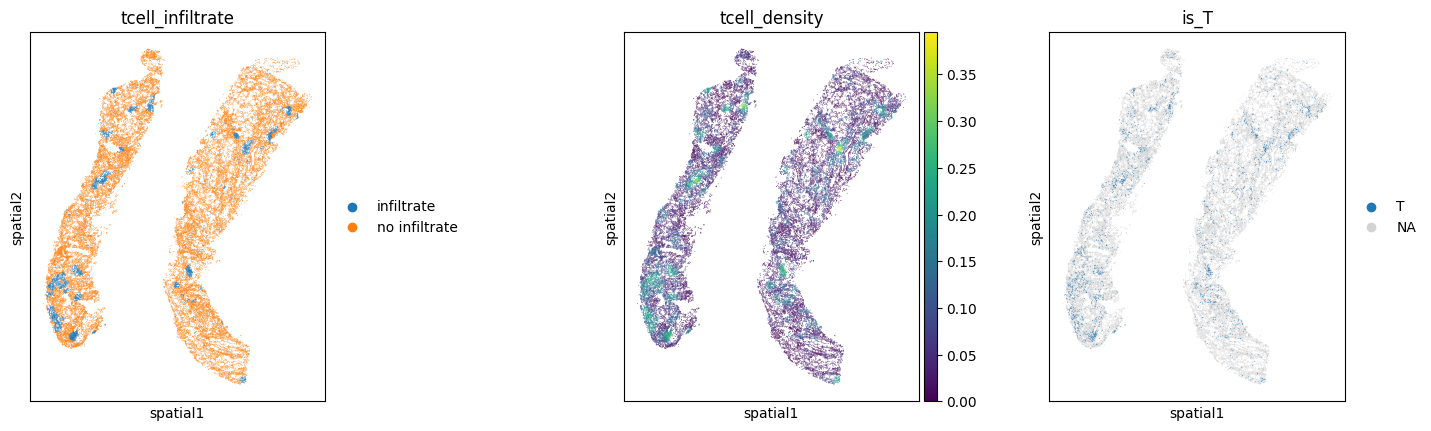

In [16]:
for sample in adata.obs["sample"].unique()[1:4]:
    ad_sub = adata[adata.obs["sample"] == sample].copy()
    sc.pl.spatial(
        ad_sub,
        color=["tcell_infiltrate", "tcell_density", "is_T"],
        spot_size=10,
        wspace=0,
    )

In [20]:
adata.write_h5ad("data/xenium/processed/05.2-kidney_tcr_infilrate.h5ad")